In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
using LinearAlgebra
using Printf
import Plots as plt


  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`


In [2]:
fixed_solvers = Dict(
    "Forward Euler"         => HD.ForwardEuler(),
    "Backward Euler"        => HD.BackwardEuler(),
    "Modified Trapezoid"    => HD.ModifiedTrap(),
    "Modified Midpoint"     => HD.ModifiedMidpoint(),
    "Richardson Extrap."    => HD.RichardsonExtrapolation(),
    "RK4"                   => HD.RK4(),
    "Adams-Bashforth 2"     => HD.AdamsBashforth2(),
    "Adams-Bashforth 3"     => HD.AdamsBashforth3(),
    "BDF2"                  => HD.BDF2()
);

In [3]:
adaptive_solvers = Dict(
    "Adaptive ABM2" => HD.AdaptiveABM2(),
    "Adaptive ABM3" => HD.AdaptiveABM3(),
    "RK23"          => HD.RK23(),
    "RK45"          => HD.RK45()
);

In [4]:
tols_adaptive = Dict(
    # Move RK45 away from the noise floor (e.g., -1 to -5)
    "RK45"          => 10.0 .^ range(-1, -5, length=6),
    
    # Keep RK23 slightly tighter, but avoid the 1e-6 floor
    "RK23"          => 10.0 .^ range(-2, -6, length=6),
    
    # LMM methods (ABM) are sensitive; give them room and fewer points 
    # to avoid the "Step size decreased below 1e-6" warning.
    "Adaptive ABM2" => 10.0 .^ range(-2, -5, length=5),
    "Adaptive ABM3" => 10.0 .^ range(-2, -5, length=5)
)
dts_fixed = 2.0 .^ (-(2:10));

In [22]:
#=

# This system isnt great as a benchmark tool as its just a straight line? I am not hitting jumps currently as that causes issues with bottlenecking the solvers. 

function sys_general(; xC=0.0, xH=1.0)
    f_therm(u, t) = [u[2], 0.0]  # dx/dt = y, dy/dt = 0
    h_therm(u) = u[2] > 0 ? (u[1] - xH) : (xC - u[1])
    Δ_therm(u) = [u[1], -u[2]]
    return HD.GeneralSystem(f_therm, h_therm, Δ_therm; direction=1)
end

function exact_general(t; x0=0.1, xC=0.0, xH=1.0)
    t1 = xH - x0 # Time to hit the first guard (0.9)
    if t < t1
        return [x0 + t, 1.0]
    end
    
    t_after = t - t1
    period = 2.0 * (xH - xC)
    t_mod = mod(t_after, period)
    half = xH - xC
    
    if t_mod < half
        return [xH - t_mod, -1.0] # Cooling phase
    else
        return [xC + (t_mod - half), 1.0] # Heating phase
    end
end
=#

#General System
sys_general() = HD.GeneralSystem((u, t) -> [-u[1]^2, -u[2]^2], u -> u[1] - 100.0, u -> [u[1], u[2]]; direction=1)
exact_general(t) = [1.0 / (1.0 + t), 1.0 / (1.0 + t)]

exact_general (generic function with 1 method)

In [6]:
#Filippov System
sys_filippov() = HD.FilippovSystem(x -> [-x[1], -x[2]], x -> [0.0, 0.0], x -> x[1] + 100.0, x -> [1.0, 0.0])
exact_filippov(t) = [exp(-t), exp(-t)]

exact_filippov (generic function with 1 method)

In [7]:
#Mechanical System
sys_mechanical() = HD.MechanicalSystem(q -> [1.0 0.0; 0.0 1.0], q -> 0.5 * (q[1]^2 + q[2]^2); guard=q -> q[1] + 100.0, normal=q -> [1.0, 0.0], e=1.0)
exact_mechanical(t) = [cos(t), sin(t), -sin(t), cos(t)]

exact_mechanical (generic function with 1 method)

In [8]:
#NH System
sys_nonholonomic() = HD.NonholonomicSystem(q -> [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 1.0] .* one(eltype(q)), q -> 0.5 * (q[1]^2 + q[2]^2); A=q -> [-sin(q[3]) cos(q[3]) 0.0], guard=q -> q[1] + 100.0, normal=q -> [1.0, 0.0, 0.0], e=1.0)
exact_nonholonomic(t) = [cos(t), 0.0, 0.0, -sin(t), 0.0, 0.0]

exact_nonholonomic (generic function with 1 method)

In [9]:
#Linear System
sys_linear() = HD.LinearSystem([-1.0 0.0; 0.0 -2.0], [1.0, 0.0], [1.0 0.0; 0.0 1.0])
exact_linear(t) = [exp(-t), exp(-2.0*t)]

exact_linear (generic function with 1 method)

In [10]:
sys_affine() = HD.AffineSystem([-1.0 0.0; 0.0 -1.0], [2.0, 3.0], [1.0, 0.0], 100.0, [1.0 0.0; 0.0 1.0], [0.0, 0.0])
exact_affine(t) = [2.0 - exp(-t), 3.0 - 2.0*exp(-t)]

exact_affine (generic function with 1 method)

In [11]:
systems = Dict(
    "General"      => (sys=sys_general,     x0=[1.0, 1.0],          tspan=(0.0, 0.5), exact=exact_general),
    "Filippov"     => (sys=sys_filippov,    x0=[1.0, 1.0],          tspan=(0.0, 2.0), exact=exact_filippov),
    "Mechanical"   => (sys=sys_mechanical,  x0=[1.0, 0.0, 0.0, 1.0], tspan=(0.0, 1.0), exact=exact_mechanical),
    "Nonholonomic" => (sys=sys_nonholonomic,x0=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], tspan=(0.0, 1.0), exact=exact_nonholonomic),
    "Linear"       => (sys=sys_linear,      x0=[1.0, 1.0],          tspan=(0.0, 2.0), exact=exact_linear),
    "Affine"       => (sys=sys_affine,      x0=[1.0, 1.0],          tspan=(0.0, 2.0), exact=exact_affine)
)

Dict{String, NamedTuple{(:sys, :x0, :tspan, :exact)}} with 6 entries:
  "Affine"       => (sys = sys_affine, x0 = [1.0, 1.0], tspan = (0.0, 2.0), exa…
  "General"      => (sys = sys_general, x0 = [1.0, 1.0], tspan = (0.0, 0.5), ex…
  "Mechanical"   => (sys = sys_mechanical, x0 = [1.0, 0.0, 0.0, 1.0], tspan = (…
  "Nonholonomic" => (sys = sys_nonholonomic, x0 = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0…
  "Filippov"     => (sys = sys_filippov, x0 = [1.0, 1.0], tspan = (0.0, 2.0), e…
  "Linear"       => (sys = sys_linear, x0 = [1.0, 1.0], tspan = (0.0, 2.0), exa…

In [12]:
function run_fixed_benchmarks(systems, solvers, dts)
    println(" FIXED STEP SOLVERS BENCHMARK (Error vs. Δt)")

    for (sys_name, spec) in systems
        plt.plot(title="Fixed Solvers: $sys_name", xlabel="Step Size (Δt)", ylabel="Terminal Error", 
                 xscale=:log10, yscale=:log10, legend=:outerright, grid=true)
        
        println("\nSystem: $sys_name")
        println(rpad("Solver", 25), " | ", "Estimated Order")

        for (solver_name, solver) in solvers
            prob = HD.prob(spec.sys(), spec.x0, spec.tspan)
            tf = spec.tspan[end]
            errors = zeros(length(dts))

            for (i, dt) in enumerate(dts)
                sol = HD.solve(prob, solver; dt_initial = dt)
                errors[i] = norm(sol.x[end] - spec.exact(tf))
            end

            # Least-squares fit for order estimate
            logh = log10.(dts)
            loge = log10.(errors)
            p = hcat(logh, ones(length(logh))) \ loge
            order = p[1]

            println(rpad(solver_name, 25), " → ", round(order, digits=4))
            plt.plot!(dts, errors, marker=:circle, label="$solver_name (p≈$(round(order, digits=2)))")
        end
        display(plt.current())
    end
end

run_fixed_benchmarks (generic function with 1 method)

In [19]:
function run_adaptive_benchmarks(systems, solvers, tols_dict)
    println(" ADAPTIVE SOLVERS BENCHMARK (Error vs. Tolerance)")

    for (sys_name, spec) in systems
        plt.plot(title="Adaptive Solvers: $sys_name", xlabel="Tolerance", ylabel="Error", 
                 xscale=:log10, yscale=:log10, legend=:outerright, grid=true)

        println("\nSystem: $sys_name")
        println(rpad("Solver", 25), " | ", "Log-Slope Error/Tol")

        for (solver_name, solver) in solvers
            prob = HD.prob(spec.sys(), spec.x0, spec.tspan)
            tf = spec.tspan[end]
        
            # Access the specific tolerance array for this solver
            tols = tols_dict[solver_name]
            errors = zeros(length(tols))

            for (i, tol) in enumerate(tols)
                sol = HD.solve(prob, solver; tol = tol)
                ######
                # DEBUG: Check if the solver actually used the tolerance we gave it
                # Does the sol object have information about steps taken?
                println("Solver: $solver_name | Tol: $tol | Steps: ", length(sol.t), " | Final Error: ", errors[i])
                ####
                errors[i] = norm(sol.x[end] - spec.exact(tf))
            end

            logtol = log10.(tols)
            loge = log10.(errors)
            p = hcat(logtol, ones(length(logtol))) \ loge
            slope = p[1]

            println(rpad(solver_name, 25), " → ", round(slope, digits=4))
            plt.plot!(tols, errors, marker=:square, label="$solver_name")
        end
        display(plt.current())
    end
end

run_adaptive_benchmarks (generic function with 1 method)

The fixed-step solvers operate with a constant step size $\Delta t$. For a solver of order $p$, the Global Truncation Error (GTE) is expected to scale as: $$\varepsilon \approx C\cdot \Delta t^p.$$ By taking the log of both sides, we obtain the linear relationship: $$\log(\varepsilon)\approx p\cdot\log(\Delta t)+\log(C).$$ On a log-log plot (like we have below), the slope of the line is exactly equal to the order $p$ of the solver. We verify our implementation by computing the slope of the error curve to ensure it matches the theoretical order (e.g., $p=1$ for Euler, $p=4$ for RK4).

Adaptive solvers do not maintain a constant $\Delta t$; instead, they adjust step sizes to maintain a local error tolerance $\tau $. The relationship between GTE ($\varepsilon$) and the tolerance ($\tau) follows from the power law: $$\varepsilon \approx \tau ^{\frac{p}{p+1}}.$$

It is also worth noting some of the strange behavior you will see in the graphs below for the adaptive solvers. Some seem a little rough instead of nice and smooth and that can be for a number of reasons. As adaptive solvers have non-fixed step size its possible to get a 'lucky' step which makes it much more/less accurate then expected.

You will also notice General Systems have a slope of 0.0. This is simply because of the example chosen (by request of our superiors) and this will be left as such. 

In [14]:
expected_fixed = Dict(
    "Forward Euler" => 1.0, "Backward Euler" => 1.0,
    "Modified Trapezoid" => 2.0, "Modified Midpoint" => 2.0,
    "Richardson Extrap." => 3.0, "RK4" => 4.0,
    "Adams-Bashforth 2" => 2.0, "Adams-Bashforth 3" => 3.0,
    "BDF2" => 2.0
)

# Power law for adaptive step controllers: p / (p+1)
expected_adaptive = Dict(
    "Adaptive ABM2" => (2.0) / (2.0 + 1.0),
    "Adaptive ABM3" => (3.0) / (3.0 + 1.0),
    "RK23"          => (3.0) / (3.0 + 1.0),
    "RK45"          => (5.0) / (5.0 + 1.0)
)

Dict{String, Float64} with 4 entries:
  "RK23"          => 0.75
  "RK45"          => 0.833333
  "Adaptive ABM2" => 0.666667
  "Adaptive ABM3" => 0.75

 FIXED STEP SOLVERS BENCHMARK (Error vs. Δt)

System: Affine
Solver                    | Estimated Order
Adams-Bashforth 3         → 2.9743
RK4                       → 3.9659
Backward Euler            → 0.9939
BDF2                      → 1.9748
Modified Midpoint         → 2.0286
Forward Euler             → 1.0059
Modified Trapezoid        → 2.0286
Richardson Extrap.        → 3.0216
Adams-Bashforth 2         → 1.9799

System: General
Solver                    | Estimated Order
Adams-Bashforth 3         → 2.198
RK4                       → 3.9616
Backward Euler            → 0.9737
BDF2                      → 1.2149
Modified Midpoint         → 2.0506
Forward Euler             → 1.0336
Modified Trapezoid        → 2.0247
Richardson Extrap.        → 3.0275
Adams-Bashforth 2         → 1.2245

System: Mechanical
Solver                    | Estimated Order
Adams-Bashforth 3         → 2.8214
RK4                       → 4.0046
Backward Euler            → 0.9892
BDF2                      → 1.8701
M

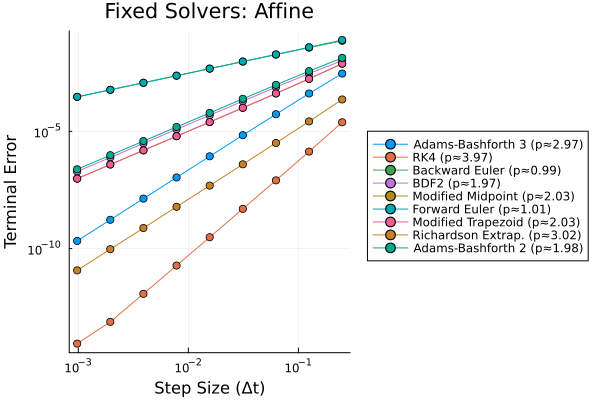

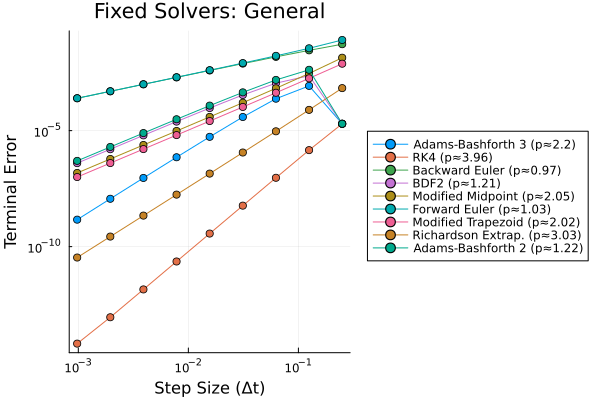

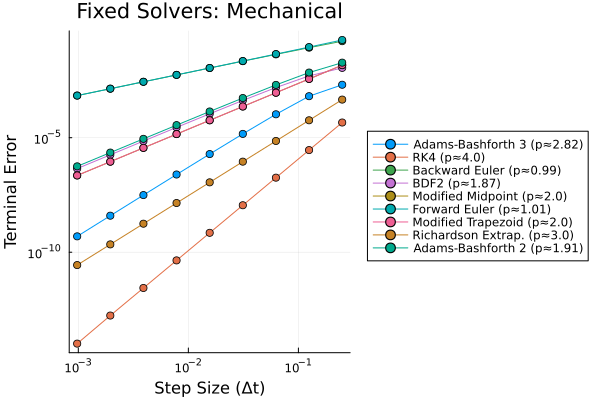

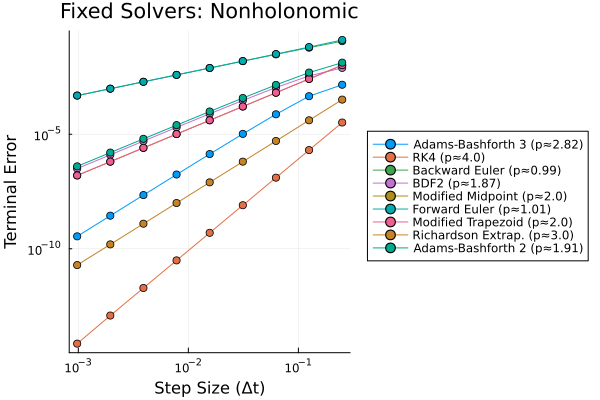

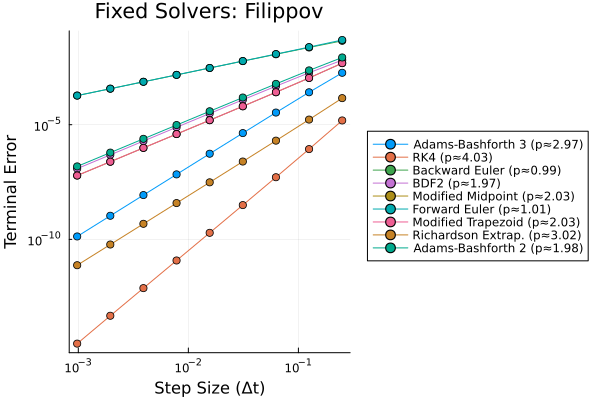

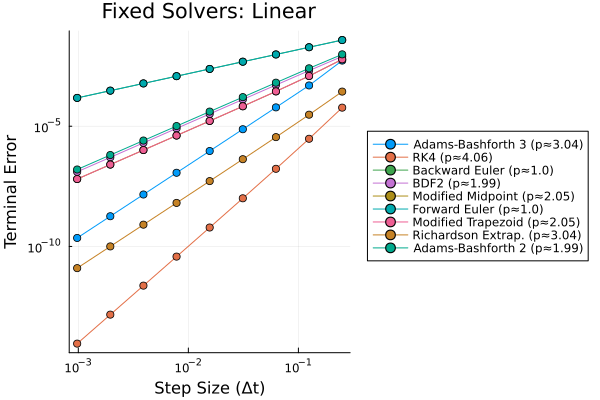

In [15]:
run_fixed_benchmarks(systems, fixed_solvers, dts_fixed)

 ADAPTIVE SOLVERS BENCHMARK (Error vs. Tolerance)

System: Affine
Solver                    | Log-Slope Error/Tol
Solver: RK23 | Tol: 0.010000000000000002 | Steps: 10 | Final Error: 0.0
Solver: RK23 | Tol: 0.001584893192461114 | Steps: 14 | Final Error: 0.0
Solver: RK23 | Tol: 0.00025118864315095795 | Steps: 22 | Final Error: 0.0
Solver: RK23 | Tol: 3.9810717055349695e-5 | Steps: 38 | Final Error: 0.0
Solver: RK23 | Tol: 6.30957344480193e-6 | Steps: 66 | Final Error: 0.0
Solver: RK23 | Tol: 1.0e-6 | Steps: 119 | Final Error: 0.0
RK23                      → 0.6486
Solver: RK45 | Tol: 0.1 | Steps: 12 | Final Error: 0.0
Solver: RK45 | Tol: 0.015848931924611134 | Steps: 20 | Final Error: 0.0
Solver: RK45 | Tol: 0.0025118864315095794 | Steps: 41 | Final Error: 0.0
Solver: RK45 | Tol: 0.00039810717055349735 | Steps: 92 | Final Error: 0.0
Solver: RK45 | Tol: 6.309573444801929e-5 | Steps: 223 | Final Error: 0.0
Solver: RK45 | Tol: 1.0e-5 | Steps: 554 | Final Error: 0.0
RK45                    

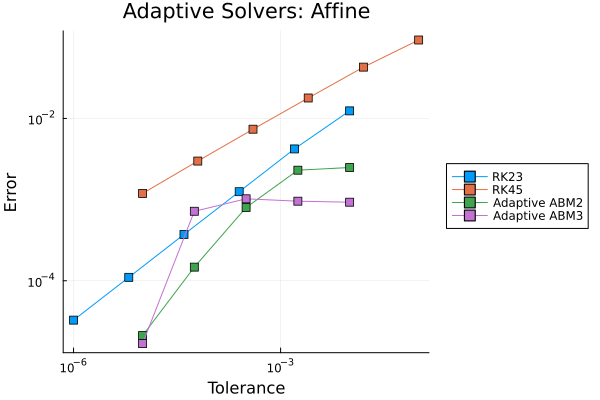

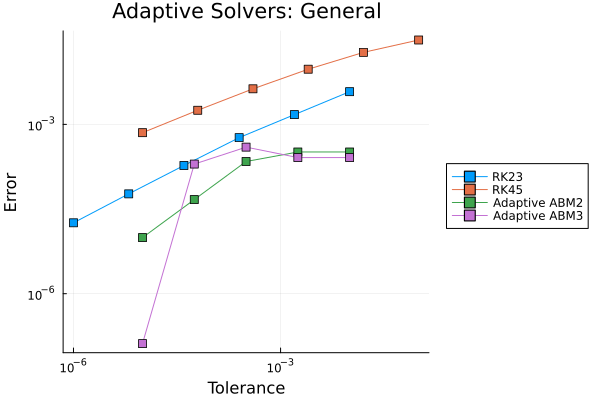

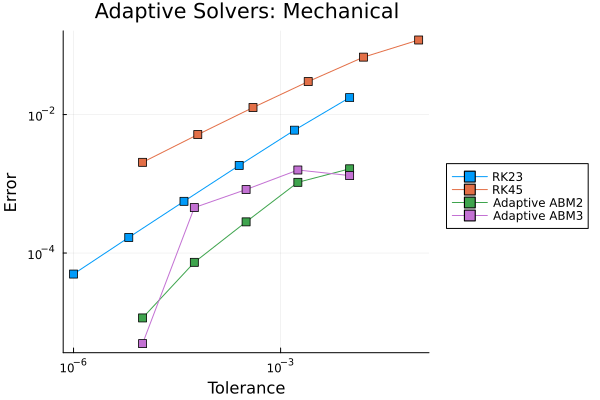

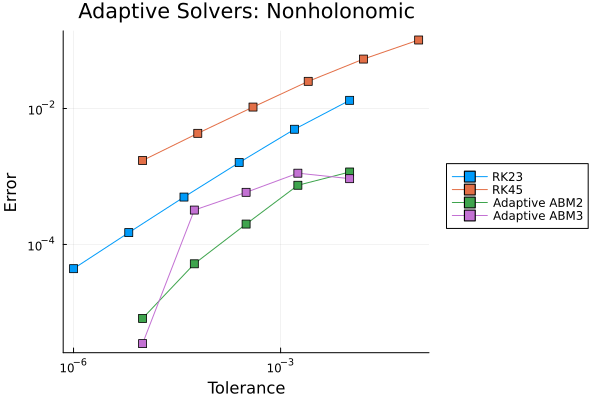

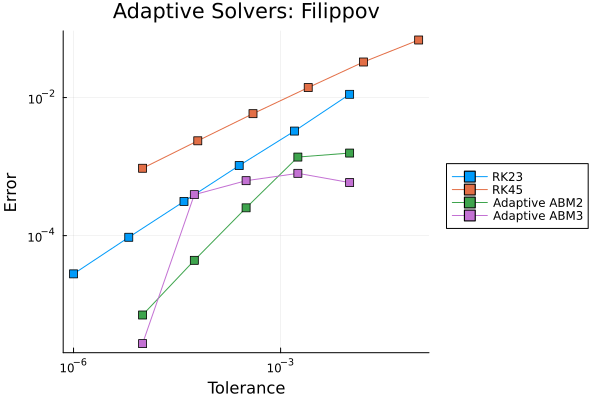

┌ Info: Time to end of simulation below minimum time step. Ending simulation at t = 1.9999990347552221
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Linear_Affine.jl:454


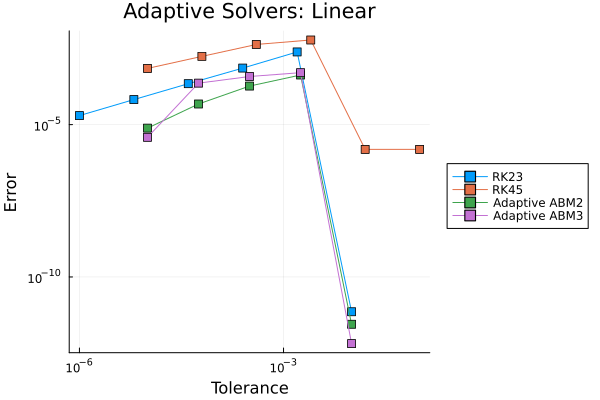

Solver: Adaptive ABM3 | Tol: 0.010000000000000002 | Steps: 200001 | Final Error: 0.0
Solver: Adaptive ABM3 | Tol: 0.0017782794100389228 | Steps: 17178 | Final Error: 0.0
Solver: Adaptive ABM3 | Tol: 0.00031622776601683794 | Steps: 54 | Final Error: 0.0
Solver: Adaptive ABM3 | Tol: 5.623413251903491e-5 | Steps: 109 | Final Error: 0.0
Solver: Adaptive ABM3 | Tol: 1.0e-5 | Steps: 145 | Final Error: 0.0
Adaptive ABM3             → -1.7601


In [20]:
run_adaptive_benchmarks(systems, adaptive_solvers, tols_adaptive)

In [21]:
function print_validation_tables(systems, fixed_solvers, adaptive_solvers, dts, tols_dict, exp_fixed, exp_adaptive)
    for (sys_name, spec) in systems
        println("\n=====================================================================")
        println(" SYSTEM: $sys_name")
        println("=====================================================================")
        
        # --- FIXED STEP TABLE ---
        println("\n[ FIXED-STEP SOLVERS ]")
        @printf("| %-22s | %-10s | %-10s | %-12s |\n", "Solver", "Expected", "Calculated", "Percent Off")
        println("-"^65)
        for (s_name, solver) in fixed_solvers
            prob = HD.prob(spec.sys(), spec.x0, spec.tspan)
            tf = spec.tspan[end]
            
            errors = [norm(HD.solve(prob, solver; dt_initial = dt).x[end] - spec.exact(tf)) for dt in dts]
            
            logh = log10.(dts)
            loge = log10.(errors)
            calc_order = (hcat(logh, ones(length(logh))) \ loge)[1]
            
            exp_order = exp_fixed[s_name]
            pct_off = exp_order != 0 ? abs(calc_order - exp_order) / exp_order * 100 : NaN
            
            @printf("| %-22s | %10.4f | %10.4f | %11.2f%% |\n", s_name, exp_order, calc_order, pct_off)
        end
        
        # --- ADAPTIVE TABLE ---
        println("\n[ ADAPTIVE SOLVERS ]")
        @printf("| %-22s | %-10s | %-10s | %-12s |\n", "Solver", "Expected", "Calculated", "Percent Off")
        println("-"^65)
        for (s_name, solver) in adaptive_solvers
            prob = HD.prob(spec.sys(), spec.x0, spec.tspan)
            tf = spec.tspan[end]
            
            # Access the specific tolerance array via the dictionary
            tols = tols_dict[s_name]
            
            errors = [norm(HD.solve(prob, solver; tol = tol).x[end] - spec.exact(tf)) for tol in tols]
            
            logtol = log10.(tols)
            loge = log10.(errors)
            calc_order = (hcat(logtol, ones(length(logtol))) \ loge)[1]
            
            exp_order = exp_adaptive[s_name]
            pct_off = exp_order != 0 ? abs(calc_order - exp_order) / exp_order * 100 : NaN
            
            @printf("| %-22s | %10.4f | %10.4f | %11.2f%% |\n", s_name, exp_order, calc_order, pct_off)
        end
        println()
    end
end

# Run the dedicated table generator using the single tolerance array
print_validation_tables(systems, fixed_solvers, adaptive_solvers, dts_fixed, tols_adaptive, expected_fixed, expected_adaptive)


 SYSTEM: Affine

[ FIXED-STEP SOLVERS ]
| Solver                 | Expected   | Calculated | Percent Off  |
-----------------------------------------------------------------
| Adams-Bashforth 3      |     3.0000 |     2.9743 |        0.86% |
| RK4                    |     4.0000 |     3.9659 |        0.85% |
| Backward Euler         |     1.0000 |     0.9939 |        0.61% |
| BDF2                   |     2.0000 |     1.9748 |        1.26% |
| Modified Midpoint      |     2.0000 |     2.0286 |        1.43% |
| Forward Euler          |     1.0000 |     1.0059 |        0.59% |
| Modified Trapezoid     |     2.0000 |     2.0286 |        1.43% |
| Richardson Extrap.     |     3.0000 |     3.0216 |        0.72% |
| Adams-Bashforth 2      |     2.0000 |     1.9799 |        1.00% |

[ ADAPTIVE SOLVERS ]
| Solver                 | Expected   | Calculated | Percent Off  |
-----------------------------------------------------------------
| RK23                   |     0.7500 |     0.6486 |     

┌ Info: Time to end of simulation below minimum time step. Ending simulation at t = 1.9999990347552221
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Linear_Affine.jl:454


| Adaptive ABM3          |     0.7500 |    -1.7601 |      334.68% |

